# CHAPTER 01: PyTorch Workflow (Linear regression model)

In [ ]:
what_were_covering = {1: "data (prepare and load)",
    2: "build model",
    3: "fitting the model to data (training)",
    4: "making predictions and evaluating a model (inference)",
    5: "saving and loading a model",
}
# print(what_were_covering)

In [ ]:
# importing necessary modules
import torch
from torch import nn
import matplotlib.pyplot as plt

# print(torch.__version__)
# print(plt.__version__)

# 1: Data (prepare and load)

In [ ]:
import math

# Making Data (linear regrassion data)
weight = 0.5
bias = 0.9

X = torch.arange(0, 1, 0.02).unsqueeze(dim=1)
Y = weight * X + bias

print(len(X), len(Y))

# Split data into training and testing sets
train_split = int(0.8 * len(X)) # 80% of data for training set

X_train, Y_train = X[:train_split], Y[:train_split]
X_test, Y_test = X[train_split:], Y[train_split:]

print(f"Length of X_train: {len(X_train)}")
print(f"Length of Y_train: {len(Y_train)}")
print(f"Length of X_test: {len(X_test)}")
print(f"Length of Y_test: {len(Y_test)}")

50 50
Length of X_train: 40
Length of Y_train: 40
Length of X_test: 10
Length of Y_test: 10


**visualizing the test and training data**

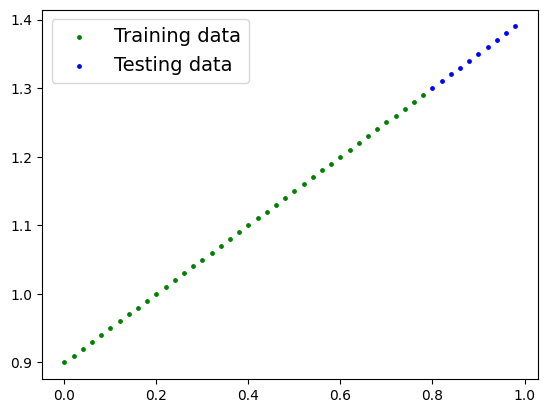

In [ ]:
def plot_prediction(train_data = X_train, train_labels = Y_train,
                    test_data = X_test, test_labels =  Y_test,
                    predictions = None):
  plt.scatter(train_data, train_labels, c='g', s = 6, label = "Training data")
  plt.scatter(test_data, test_labels, c='b', s = 6, label = "Testing data")
  if predictions is not None:
    plt.scatter(test_data, predictions, c='r', s = 6, label = "Predictions")
  plt.legend(prop = {"size": 14})
  plt.show()

plot_prediction()

# 2: Build Model

In [ ]:
from torch import nn

class LinearRegressionModel(nn.Module):
  def __init__(self):
    super().__init__()
    self.weights = nn.Parameter(torch.randn(1,
                                            requires_grad=True,
                                            dtype=torch.float))
    self.bias = nn.Parameter(torch.randn(1,
                                         requires_grad=True,
                                         dtype=torch.float))

  # Forward method to define the computation in the model
  def forward(self, x: torch.Tensor) -> torch.Tensor:
    return self.weights * x + self.bias

The above parameters are having random value but we need to make close the parameter value to the as close as possible to idial value in the above case "Weight and Bias"

In [ ]:
torch.manual_seed(42)
model_0 = LinearRegressionModel()
model_0.parameters() #genral way of demonstration of parameters
list(model_0.parameters()), weight, bias

([Parameter containing:
  tensor([0.3367], requires_grad=True),
  Parameter containing:
  tensor([0.1288], requires_grad=True)],
 0.5,
 0.9)

# 3: Fitting the model to data (training)

In [ ]:
with torch.inference_mode():
  y_pred = model_0(X_test)
y_pred

tensor([[0.3982],
        [0.4049],
        [0.4116],
        [0.4184],
        [0.4251],
        [0.4318],
        [0.4386],
        [0.4453],
        [0.4520],
        [0.4588]])

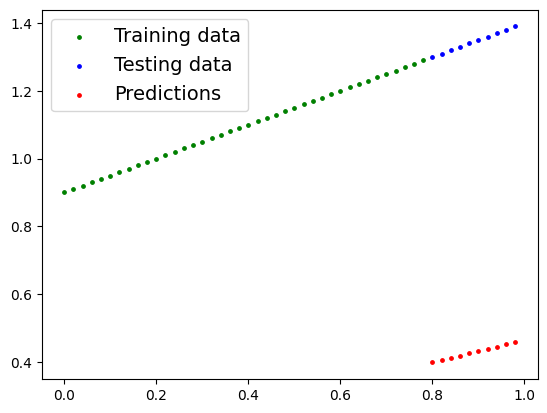

In [ ]:
plot_prediction(predictions = y_pred)

# 4: Making predictions and evaluating a model (inference)
* **Loss Function**
* **Optimozer**

In [ ]:
import torch.optim

#creating loss function
loss_fn = nn.L1Loss()

#creating Optimizer function
optimizer = torch.optim.SGD(params= model_0.parameters(), lr = 0.01) # Changed learning rate to 0.01
loss_fn, optimizer

(L1Loss(),
 SGD (
 Parameter Group 0
     dampening: 0
     differentiable: False
     foreach: None
     fused: None
     lr: 0.01
     maximize: False
     momentum: 0
     nesterov: False
     weight_decay: 0
 ))

#Traning loop & Training loop

In [ ]:
torch.manual_seed(42)

traing_loos = []
testing_loos = []
epoch_count = []

epochs = 200

for epoch in range(epochs):

  model_0.train()

  y_pred = model_0(X_train)

  loss = loss_fn(y_pred, Y_train)

  optimizer.zero_grad()

  loss.backward()

  optimizer.step()

# TESTING
  model_0.eval()
  with torch.inference_mode():
    y_pred_new = model_0(X_test)
    # Y_test is already torch.float, so .type(torch.float) is redundant but harmless
    test_loss = loss_fn(y_pred_new, Y_test)

    if epoch % 10 == 0:
      epoch_count.append(epoch)
      testing_loos.append(test_loss.item()) # Use .item() to get scalar value
      traing_loos.append(loss.item())       # Use .item() to get scalar value
      print(f"Epoch: {epoch} | MAE Train Loss: {loss.item():.4f} | MAE Test Loss: {test_loss.item():.4f}") # Format for readability

Epoch: 0 | MAE Train Loss: 0.8349 | MAE Test Loss: 0.9031
Epoch: 10 | MAE Train Loss: 0.7197 | MAE Test Loss: 0.7684
Epoch: 20 | MAE Train Loss: 0.6045 | MAE Test Loss: 0.6336
Epoch: 30 | MAE Train Loss: 0.4893 | MAE Test Loss: 0.4989
Epoch: 40 | MAE Train Loss: 0.3740 | MAE Test Loss: 0.3642
Epoch: 50 | MAE Train Loss: 0.2588 | MAE Test Loss: 0.2295
Epoch: 60 | MAE Train Loss: 0.1436 | MAE Test Loss: 0.0948
Epoch: 70 | MAE Train Loss: 0.0315 | MAE Test Loss: 0.0333
Epoch: 80 | MAE Train Loss: 0.0207 | MAE Test Loss: 0.0470
Epoch: 90 | MAE Train Loss: 0.0172 | MAE Test Loss: 0.0394
Epoch: 100 | MAE Train Loss: 0.0138 | MAE Test Loss: 0.0312
Epoch: 110 | MAE Train Loss: 0.0103 | MAE Test Loss: 0.0236
Epoch: 120 | MAE Train Loss: 0.0069 | MAE Test Loss: 0.0153
Epoch: 130 | MAE Train Loss: 0.0035 | MAE Test Loss: 0.0070
Epoch: 140 | MAE Train Loss: 0.0026 | MAE Test Loss: 0.0085
Epoch: 150 | MAE Train Loss: 0.0026 | MAE Test Loss: 0.0085
Epoch: 160 | MAE Train Loss: 0.0026 | MAE Test Loss

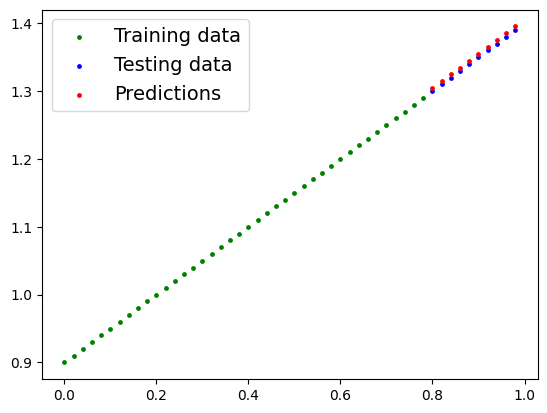

In [ ]:
# model_0.eval()
with torch.inference_mode():
  y_pred_new = model_0(X_test)

plot_prediction(predictions=y_pred_new)

In [ ]:
model_0.state_dict()

OrderedDict([('weights', tensor([0.5047])), ('bias', tensor([0.9008]))])

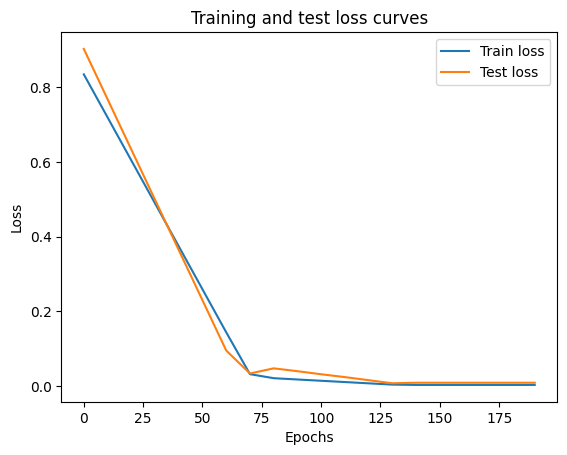

In [ ]:
# Plot the loss curves
plt.plot(epoch_count, traing_loos, label="Train loss")
plt.plot(epoch_count, testing_loos, label="Test loss")
plt.title("Training and test loss curves")
plt.ylabel("Loss")
plt.xlabel("Epochs")
plt.legend();

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

In [ ]:
# Find our model's learned parameters
print("The model learned the following values for weights and bias:")
print(model_0.state_dict())
print("\nAnd the original values for weights and bias are:")
print(f"weights: {weight}, bias: {bias}")

The model learned the following values for weights and bias:
OrderedDict({'weights': tensor([0.5047]), 'bias': tensor([0.9008])})

And the original values for weights and bias are:
weights: 0.5, bias: 0.9


#  5: Saving and loading a model

In [ ]:
from pathlib import Path

# 1. Create models directory
MODEL_PATH = Path("models")
MODEL_PATH.mkdir(parents=True, exist_ok=True)

# 2. Create model save path
MODEL_NAME = "01_Pytorch_workflow.pth"
MODEL_SAVE_PATH = MODEL_PATH / MODEL_NAME

# 3. Save the model state dict
print(f"Saving model to: {MODEL_SAVE_PATH}")
torch.save(obj=model_0.state_dict(),
           f=MODEL_SAVE_PATH)

Saving model to: models/01_Pytorch_workflow.pth


In [ ]:
model_0.state_dict()

OrderedDict([('weights', tensor([0.5047])), ('bias', tensor([0.9008]))])

In [ ]:
# To load in a saved state_dict we have to instantiate a new instance of our model class
loaded_model_0 = LinearRegressionModel()

# Load the saved state_dict of model_0 (this will update the new instance with updated parameters)
loaded_model_0.load_state_dict(torch.load(f=MODEL_SAVE_PATH))

<All keys matched successfully>

In [ ]:
loaded_model_0.state_dict()

OrderedDict([('weights', tensor([0.5047])), ('bias', tensor([0.9008]))])

In [ ]:
# Make some predictions with our loaded model
loaded_model_0.eval()
with torch.inference_mode():
  loaded_model_preds = loaded_model_0(X_test)

loaded_model_preds

tensor([[1.3045],
        [1.3146],
        [1.3247],
        [1.3348],
        [1.3449],
        [1.3550],
        [1.3651],
        [1.3752],
        [1.3853],
        [1.3954]])

In [ ]:
# Make some models preds
model_0.eval()
with torch.inference_mode():
  y_preds = model_0(X_test)

y_preds

tensor([[1.3045],
        [1.3146],
        [1.3247],
        [1.3348],
        [1.3449],
        [1.3550],
        [1.3651],
        [1.3752],
        [1.3853],
        [1.3954]])

In [ ]:
# Compare loaded model preds with original model preds
y_preds == loaded_model_preds

tensor([[True],
        [True],
        [True],
        [True],
        [True],
        [True],
        [True],
        [True],
        [True],
        [True]])